In [22]:
# ==========================================================
# Health Risk Model Training V2
# ==========================================================

import warnings

warnings.filterwarnings("ignore")

import time
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix

)

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

print("=" * 70)

print("Health Risk Model Training V2")

print("=" * 70)

Health Risk Model Training V2


In [23]:
from pathlib import Path
import joblib

DATA_DIR = Path("../data/processed")

data = joblib.load(DATA_DIR / "health_dataset.pkl")

print(type(data))
print()

if isinstance(data, tuple):
    print("Tuple Length:", len(data))
    for i, item in enumerate(data):
        print(f"Item {i}: {type(item)}")

elif isinstance(data, dict):
    print("Keys:")
    print(data.keys())

else:
    print(data)

<class 'dict'>

Keys:
dict_keys(['X_train', 'X_test', 'y_train', 'y_test'])


In [24]:
# ==========================================================
# Load Processed Dataset
# ==========================================================

from pathlib import Path
import joblib

DATA_DIR = Path("../data/processed")

data = joblib.load(
    DATA_DIR / "health_dataset.pkl"
)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("=" * 70)
print("Processed Dataset Loaded")
print("=" * 70)

print()

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

print()

print("Total Features :", X_train.shape[1])

Processed Dataset Loaded

Train Shape : (80000, 105)
Test Shape  : (20000, 105)

Total Features : 105


In [25]:
feature_df.to_csv("feature_list.csv", index=False)

print(feature_df)

               Feature
1                  Age
2            Age_Group
3               Gender
4            Height_cm
5            Weight_kg
..                 ...
101   Respiratory_Risk
102  Neurological_Risk
103     Metabolic_Risk
104     Lifestyle_Risk
105         Trend_Risk

[105 rows x 1 columns]


In [26]:
feature_df.to_csv("feature_list.csv", index=False)

In [27]:
feature_list = pd.DataFrame({
    "Feature": X_train.columns
})

feature_list.to_csv("feature_list.csv", index=False)

print("Saved!")

Saved!


In [28]:
# ==========================================================
# Remove Leakage Features
# ==========================================================

DROP_COLUMNS = [

    "Clinical_Score",

    "Cardiovascular_Risk",
    "Respiratory_Risk",
    "Neurological_Risk",
    "Metabolic_Risk",
    "Lifestyle_Risk",
    "Trend_Risk"

]

X_train = X_train.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

X_test = X_test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

print("=" * 60)
print("Leakage Features Removed")
print("=" * 60)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

print("Total Features :", X_train.shape[1])

Leakage Features Removed
Train Shape : (80000, 99)
Test Shape  : (20000, 99)
Total Features : 99


In [29]:
print(X_train.columns.tolist())

['Age', 'Age_Group', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Group', 'Ethnicity', 'Diabetes', 'Diabetes_Severity', 'Hypertension', 'Hypertension_Severity', 'Heart_Disease', 'Heart_Disease_Severity', 'Stroke', 'Stroke_Severity', 'COPD', 'COPD_Severity', 'Asthma', 'Asthma_Severity', 'Kidney_Disease', 'Kidney_Disease_Severity', 'Parkinsons', 'Parkinsons_Severity', 'Alzheimers', 'Alzheimers_Severity', 'Thyroid', 'Thyroid_Severity', 'Liver_Disease', 'Liver_Disease_Severity', 'Arthritis', 'Arthritis_Severity', 'Cancer', 'Cancer_Severity', 'Osteoporosis', 'Osteoporosis_Severity', 'Depression', 'Depression_Severity', 'Anemia', 'Anemia_Severity', 'Uses_Insulin', 'Uses_Metformin', 'Uses_Glimepiride', 'Uses_Amlodipine', 'Uses_Losartan', 'Uses_Aspirin', 'Uses_Atorvastatin', 'Uses_Salbutamol', 'Uses_Levodopa', 'Uses_Donepezil', 'Medication_Adherence', 'Smoking', 'Alcohol', 'Mobility', 'Memory_Status', 'Exercise_Level', 'Diet_Quality', 'Water_Intake_Liters', 'Baseline_Heart_Rate', 'Baselin

In [30]:
# ==========================================================
# Initialize Models
# ==========================================================

MODELS = {

    "Random Forest": RandomForestClassifier(

        n_estimators=300,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1

    ),

    "XGBoost": XGBClassifier(

        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        random_state=42,
        eval_metric="mlogloss",
        tree_method="hist"

    ),

    "LightGBM": LGBMClassifier(

        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42

    ),

    "CatBoost": CatBoostClassifier(

        iterations=300,
        learning_rate=0.05,
        depth=8,
        random_seed=42,
        verbose=False

    )

}

print("Models Initialized Successfully")

Models Initialized Successfully


In [31]:
# ==========================================================
# Train Models
# ==========================================================

results = {}

trained_models = {}

for model_name, model in MODELS.items():

    print("=" * 70)
    print(f"TRAINING {model_name.upper()}")
    print("=" * 70)

    start = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    results[model_name] = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Training_Time": training_time

    }

    trained_models[model_name] = model

    print()

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Training Time : {training_time:.2f} sec")

    print()

TRAINING RANDOM FOREST

Accuracy : 0.9453
Precision : 0.9453
Recall : 0.9453
F1 : 0.9453
Training Time : 29.90 sec

TRAINING XGBOOST

Accuracy : 0.9681
Precision : 0.9682
Recall : 0.9681
F1 : 0.9681
Training Time : 19.37 sec

TRAINING LIGHTGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3787
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 99
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Accuracy : 0.9719
Precision : 0.9720
Recall : 0.9719
F1 :

In [32]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame(results).T

comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

comparison

,Accuracy,Precision,Recall,F1,Training_Time
LightGBM,0.97195,0.972029,0.97195,0.971933,10.363173
XGBoost,0.96815,0.968157,0.96815,0.968121,19.369583
CatBoost,0.96420,0.964192,0.96420,0.964079,60.044112
Random Forest,0.94530,0.945323,0.94530,0.945260,29.901040


In [33]:
# ==========================================================
# Best Model
# ==========================================================

best_model_name = comparison.index[0]

best_model = trained_models[best_model_name]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(best_model_name)

BEST MODEL
LightGBM


In [34]:
# ==========================================================
# Save Final Health Risk Model
# ==========================================================

from pathlib import Path
import joblib

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Best model
best_model_name = comparison.index[0]
best_model = trained_models[best_model_name]

# Save model
joblib.dump(
    best_model,
    MODEL_DIR / "health_risk_model_v2.pkl"
)

# Save feature order
joblib.dump(
    list(X_train.columns),
    MODEL_DIR / "health_feature_columns_v2.pkl"
)

print("=" * 60)
print("FINAL HEALTH MODEL SAVED")
print("=" * 60)
print("Best Model :", best_model_name)
print("Accuracy   :", comparison.iloc[0]["Accuracy"])

FINAL HEALTH MODEL SAVED
Best Model : LightGBM
Accuracy   : 0.97195


In [35]:
joblib.dump(
    health_encoder,
    MODEL_DIR / "health_label_encoder_v2.pkl"
)

NameError: name 'health_encoder' is not defined

In [ ]:
import os

print(os.listdir("../models"))

['alert_features.pkl', 'alert_feature_encoders.pkl', 'alert_label_encoder.pkl', 'alert_scaler.pkl', 'best_health_model.pkl', 'clinical_event_feature_encoders.pkl', 'clinical_event_label_encoder.pkl', 'clinical_event_model.pkl', 'disease_models', 'encoders', 'health_features.pkl', 'health_feature_columns_v2.pkl', 'health_feature_encoders.pkl', 'health_label_encoder.pkl', 'health_risk_model_v2.pkl', 'health_scaler.pkl']


In [36]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

predictions = best_model.predict(X_test)

print("=" * 70)
print(f"{best_model_name.upper()} CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        predictions
    )
)

LIGHTGBM CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.98      0.98      0.98      2792
           2       0.98      0.96      0.97      6766
           3       0.95      0.97      0.96      3795
           4       0.98      0.99      0.98      6637

    accuracy                           0.97     20000
   macro avg       0.93      0.92      0.92     20000
weighted avg       0.97      0.97      0.97     20000



In [37]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

cm_df = pd.DataFrame(cm)

cm_df

,0,1,2,3,4
0,7,3,0,0,0
1,2,2738,0,52,0
2,0,0,6475,138,153
3,0,58,61,3676,0
4,0,0,94,0,6543


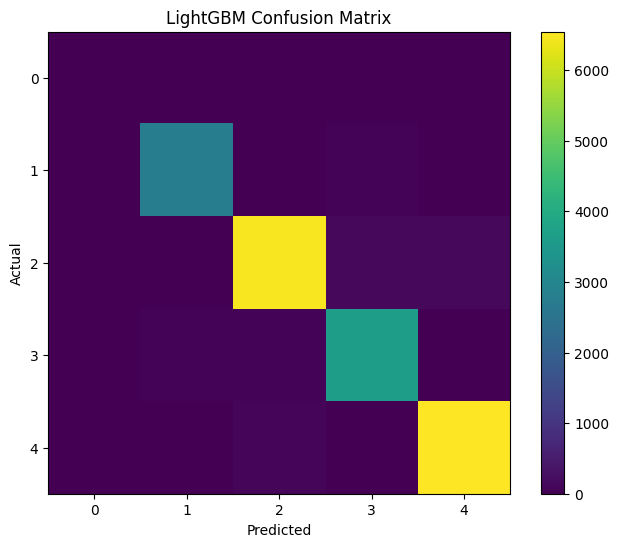

In [38]:
# ==========================================================
# Confusion Matrix Heatmap
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(cm, interpolation="nearest")

plt.title(f"{best_model_name} Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [39]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(25)

,Feature,Importance
83,Systolic_BP_Deviation,4098
71,Scenario,3296
82,Heart_Rate_Deviation,3213
85,SpO2_Deviation,2988
70,Health_Index,1902
64,Cardiovascular_Score,1817
87,Respiratory_Deviation,1731
78,Sleep_Hours,1638
93,High_Risk_Disease_Count,1487
66,Neurological_Score,1446
